In [3]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

In [4]:
def random_clifford_t_block(qc, q1, q2, add_t, p_t=0.2):
    for q in [q1, q2]:
        r = np.random.randint(4)
        if r == 0:
            qc.h(q)
        elif r == 1:
            qc.s(q)
        elif r == 2:
            qc.h(q)
            qc.s(q)

    if np.random.rand() < 0.5:
        qc.cx(q1, q2)
    else:
        qc.cx(q2, q1)

    if add_t:
        if np.random.rand() < p_t:
            qc.t(q1)
        if np.random.rand() < p_t:
            qc.t(q2)


def build_circuit_2d(Lx, Ly, d, add_t, p_t=0.2):
    N = Lx * Ly
    qc = QuantumCircuit(N, N)

    def idx(x, y):
        return y * Lx + x

    for layer in range(d):
        direction = layer % 2
        offset = (layer // 2) % 2

        gates_added = False
        if direction == 0:
            for y in range(Ly):
                for x in range(offset, Lx - 1, 2):
                    random_clifford_t_block(qc, idx(x, y), idx(x + 1, y), add_t=add_t, p_t=p_t)
                    gates_added = True
        else:
            for x in range(Lx):
                for y in range(offset, Ly - 1, 2):
                    random_clifford_t_block(qc, idx(x, y), idx(x, y + 1), add_t=add_t, p_t=p_t)
                    gates_added = True

        if gates_added:
            qc.barrier()

    qc.measure(range(N), range(N))
    return qc


def projected_collision_prob(counts, n_A):
    """
    Post-select on subsystem A (qubits 0..n_A-1) = 00...0,
    then return the collision probability of subsystem B conditioned on that outcome.
    Qiskit bitstrings are little-endian: rightmost n_A bits = subsystem A.
    """
    target_A = '0' * n_A
    b_counts = defaultdict(int)

    for bitstring, count in counts.items():
        bitstring = bitstring.replace(' ', '')
        a_bits = bitstring[-n_A:]   # qubits 0..n_A-1
        b_bits = bitstring[:-n_A]   # qubits n_A..N-1

        if a_bits == target_A:
            b_counts[b_bits] += count

    total = sum(b_counts.values())
    if total == 0:
        return None  # no shots landed on A=00...0

    probs = np.array(list(b_counts.values())) / total
    return np.sum(probs**2)


d=2, N=4, shots=2000
d=3, N=4, shots=2000
d=4, N=4, shots=2000
d=5, N=4, shots=2000
d=6, N=4, shots=2000
d=7, N=4, shots=2000
d=8, N=4, shots=2000
d=9, N=4, shots=2000
d=10, N=4, shots=2000
d=11, N=4, shots=2000
d=2, N=9, shots=2000
d=3, N=9, shots=2000
d=4, N=9, shots=2000
d=5, N=9, shots=2000
d=6, N=9, shots=2000
d=7, N=9, shots=2000
d=8, N=9, shots=2000
d=9, N=9, shots=2000
d=10, N=9, shots=2000
d=11, N=9, shots=2000
d=2, N=16, shots=2000
d=3, N=16, shots=2000
d=4, N=16, shots=2000
d=5, N=16, shots=2000
d=6, N=16, shots=2000
d=7, N=16, shots=2000
d=8, N=16, shots=2000
d=9, N=16, shots=2000
d=10, N=16, shots=2000
d=11, N=16, shots=2000
d=2, N=25, shots=2000
d=3, N=25, shots=2000
d=4, N=25, shots=2000
d=5, N=25, shots=2000
d=6, N=25, shots=2000
d=7, N=25, shots=2000
d=8, N=25, shots=2000
d=9, N=25, shots=2000
d=10, N=25, shots=2000
d=11, N=25, shots=2000


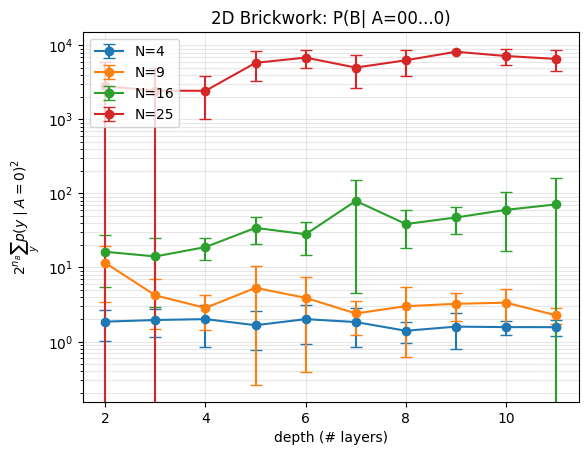

In [5]:
# Vary depth, fixed N
L_values = list(range(2, 6))
depth_values = list(range(2, 12))
samples_per_n = 10
shots = 2000
add_t = True


sim = AerSimulator(
    method="matrix_product_state",
    mps_sample_measure_algorithm="mps_apply_measure",
    matrix_product_state_max_bond_dimension=64,
    matrix_product_state_truncation_threshold=1e-8,
    max_parallel_threads=0,
    mps_omp_threads=0
)

for L in L_values:
    N = L * L
    n_A = N // 2
    n_B = N - n_A
    avg_prob, std_prob = [], []

    for d in depth_values:
        print(f"d={d}, N={N}, shots={shots}")
        vals = []

        for _ in range(samples_per_n):
            qc = build_circuit_2d(L, L, d, add_t, p_t=0.15)
            tqc = transpile(qc, basis_gates=['h', 's', 'sdg', 't', 'tdg', 'cx', 'measure'], optimization_level=0)
            counts = sim.run(tqc, shots=shots).result().get_counts()

            cp_est = projected_collision_prob(counts, n_A)
            if cp_est is not None:
                vals.append((2 ** n_B) * cp_est)

        avg_prob.append(np.mean(vals) if vals else np.nan)
        std_prob.append(np.std(vals) if vals else np.nan)

    plt.errorbar(depth_values, avg_prob, yerr=std_prob, marker='o', capsize=4, label=f"N={N}")

plt.xlabel("depth (# layers)")
plt.ylabel(r"$2^{n_B} \sum_y p(y \mid A{=}0)^2$")
plt.yscale('log')
plt.title(f"2D Brickwork: P(B| A=00...0)")
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()
